In [11]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from pathlib import Path
import sys; sys.path.insert(0, str(Path.cwd().parent / "src"))
from prediction.dataset import PREDICTOR_COLS, TARGET_CATEGORIES, build_model_table

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# Build the Chicago and Houston crime tables
sns.set_theme(style="whitegrid")
hou = build_model_table("houston")
chi = build_model_table("chicago")
tables = {"houston": hou, "chicago": chi}   # already built above

houston: model table (1629, 42) → data/processed/prediction/houston_model_table.parquet
chicago: model table (2164, 42) → data/processed/prediction/chicago_model_table.parquet


In [24]:
chi.info()

<class 'pandas.DataFrame'>
Index: 2164 entries, 0 to 2238
Data columns (total 42 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   geoid              2164 non-null   str    
 1   det_pct            2164 non-null   float64
 2   in_household_pct   2164 non-null   float64
 3   moved1yr_pct       2164 non-null   float64
 4   Division           2164 non-null   float64
 5   city_centers_dist  2164 non-null   float64
 6   pop_est_5mile      2164 non-null   float64
 7   pop_ch_1mile       2164 non-null   float64
 8   vacant_pct         2164 non-null   float64
 9   clip_liens_pct     2164 non-null   float64
 10  within_city        2164 non-null   bool   
 11  population         2164 non-null   float64
 12  cl_total_count     2164 non-null   float64
 13  violent_count      2164 non-null   float64
 14  property_count     2164 non-null   float64
 15  assault_count      2164 non-null   float64
 16  murder_count       2164 non-null   float

In [13]:
# Check percentile values of columns
def describe_cols(df, cols):
    d = df[cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
    d["skew"] = df[cols].skew()
    d["n_missing"] = df[cols].isna().sum()
    return d.round(2)

for city, df in tables.items():
    print(f"\n{'='*70}\n{city.upper()} — predictor summary\n{'='*70}")
    display(describe_cols(df, PREDICTOR_COLS))


HOUSTON — predictor summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing
det_pct,1629.0,47.52,37.42,0.00,0.00,0.00,7.73,45.96,84.84,100.00,100.00,100.00,0.08,0
in_household_pct,1629.0,98.91,5.96,0.00,76.72,96.87,99.51,100.00,100.00,100.00,100.00,100.00,-11.79,0
moved1yr_pct,1629.0,17.05,11.30,0.00,1.74,3.27,8.75,14.47,23.11,40.20,49.93,66.50,1.10,0
city_centers_dist,1629.0,19.64,8.73,1.00,10.00,10.00,15.00,20.00,20.00,30.00,50.00,50.00,1.72,0
pop_est_5mile,1629.0,404239.40,126370.44,57007.00,134393.36,187750.80,317643.00,395354.00,506825.00,603121.20,634320.56,642921.00,-0.11,0
pop_ch_1mile,1629.0,-0.65,9.56,-59.29,-29.62,-18.79,-5.88,1.18,5.78,11.63,16.64,24.26,-1.04,0
vacant_pct,1629.0,2.91,3.89,0.00,0.00,0.00,0.66,1.61,3.62,9.78,17.88,42.03,3.80,0
clip_liens_pct,1629.0,0.02,0.47,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.24,16.67,30.86,0



CHICAGO — predictor summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing
det_pct,2164.0,32.40,30.41,0.00,0.00,0.00,6.92,22.07,51.61,95.30,100.00,100.00,0.84,0
in_household_pct,2164.0,98.61,5.33,4.98,80.04,93.56,99.38,99.89,100.00,100.00,100.00,100.00,-9.12,0
moved1yr_pct,2164.0,13.56,9.19,0.00,0.71,2.18,6.06,11.73,18.68,32.37,39.12,55.36,0.92,0
city_centers_dist,2164.0,18.77,6.87,1.00,5.00,10.00,15.00,20.00,20.00,30.00,30.00,30.00,0.31,0
pop_est_5mile,2164.0,875513.22,273621.78,208801.00,261293.53,421187.15,686500.75,867731.00,1083399.50,1325543.25,1393617.73,1437536.00,-0.09,0
pop_ch_1mile,2164.0,3.73,6.07,-18.62,-15.06,-8.45,0.82,4.63,8.06,11.45,14.74,18.14,-0.96,0
vacant_pct,2164.0,3.66,3.72,0.00,0.09,0.41,1.24,2.37,4.72,11.94,17.46,25.82,2.03,0
clip_liens_pct,2164.0,0.02,0.14,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.54,4.55,19.09,0


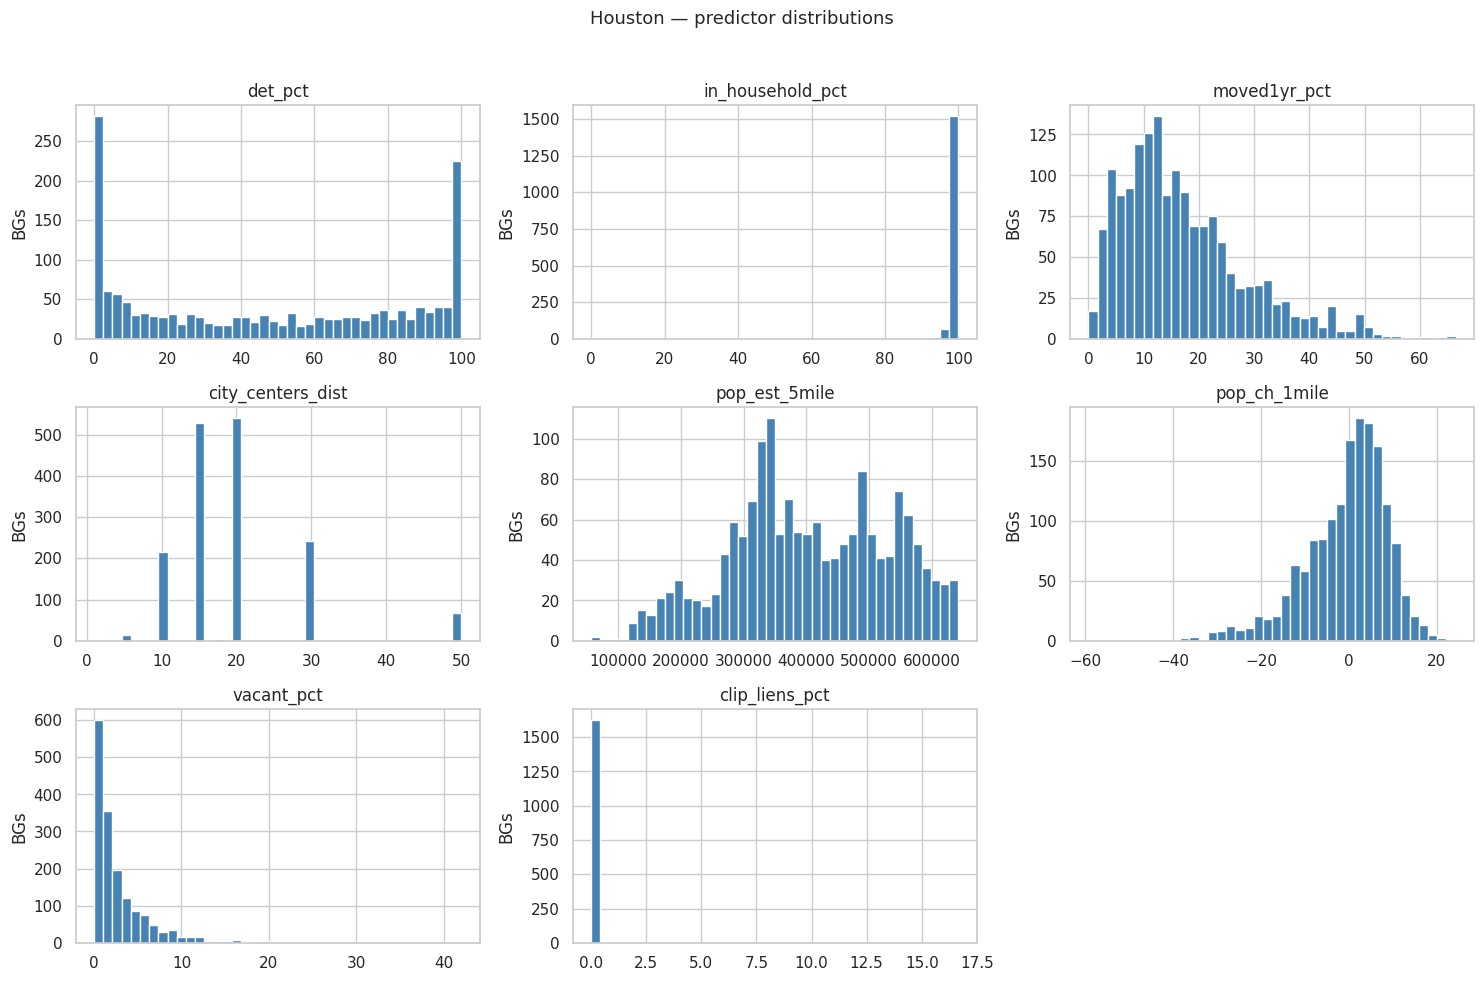

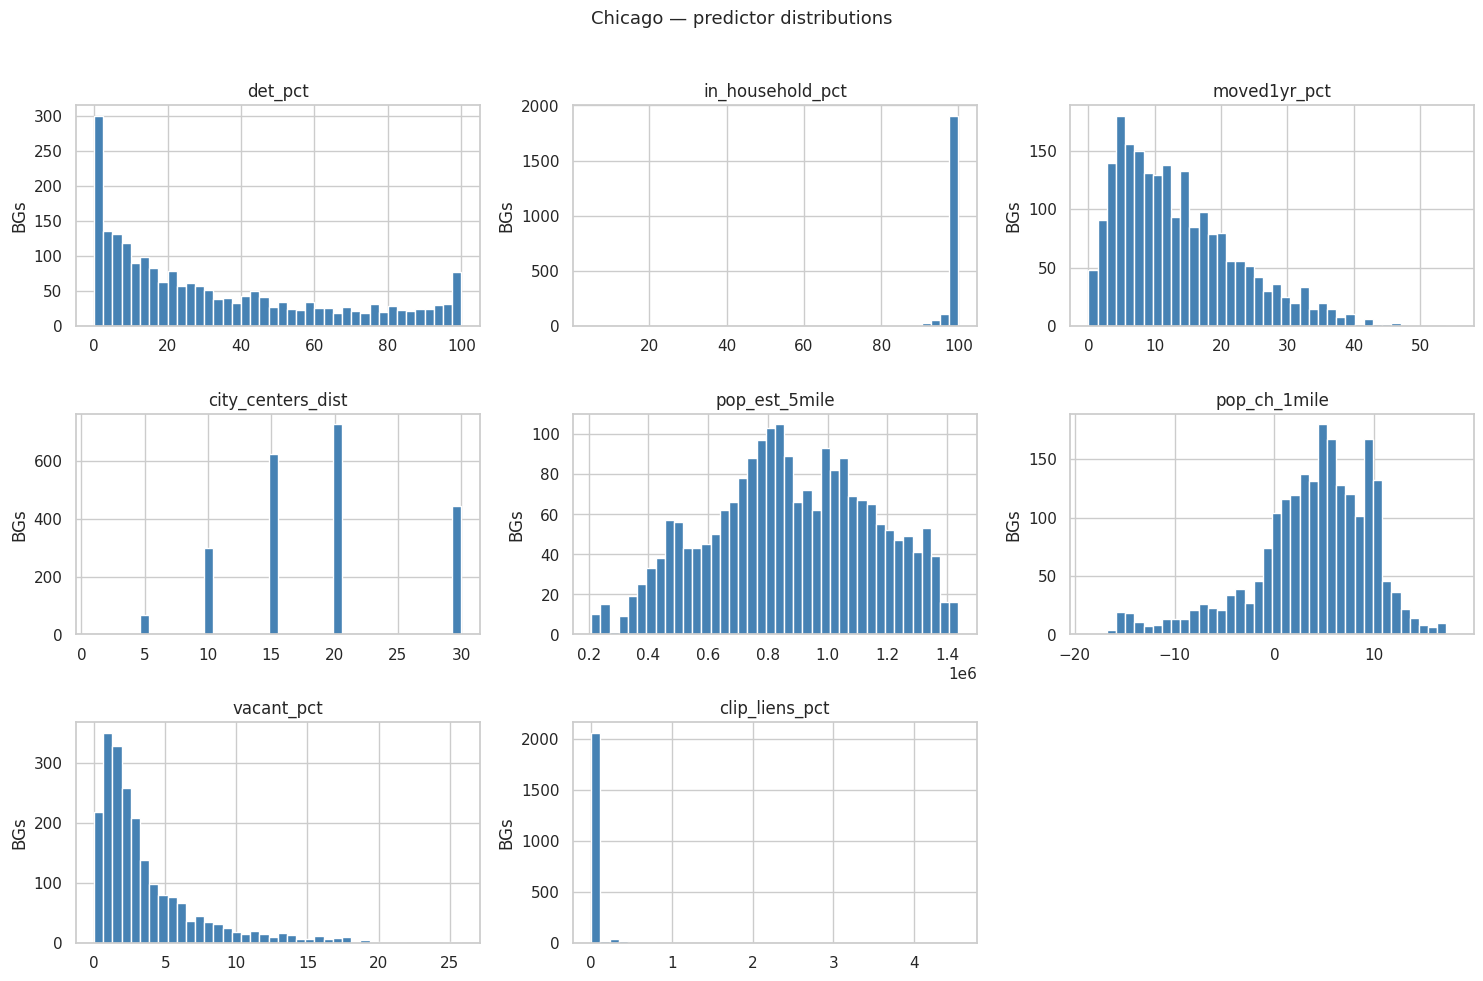

In [14]:
# Predictor distributions
def plot_grid(df, cols, title, bins=40, color="steelblue"):
    ncol = 3
    nrow = int(np.ceil(len(cols) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.2 * nrow))
    for ax, c in zip(axes.ravel(), cols):
        ax.hist(df[c].dropna(), bins=bins, color=color, edgecolor="white")
        ax.set_title(c); ax.set_ylabel("BGs")
    for ax in axes.ravel()[len(cols):]:
        ax.set_visible(False)
    fig.suptitle(title, fontsize=13, y=1.02); fig.tight_layout(); plt.show()

for city, df in tables.items():
    plot_grid(df, PREDICTOR_COLS, f"{city.title()} — predictor distributions")

In [15]:
# Target summary
# pct_zero is the key column: a target with very high zero-fraction is a poor
# candidate for OLS on log-count and may need pooling or a count model.
def target_summary(df):
    rows = []
    for c in TARGET_CATEGORIES:
        cnt = df[f"{c}_count"]
        rows.append({
            "target": c, "total": int(cnt.sum()), "mean": round(cnt.mean(), 2),
            "p50": cnt.median(), "p95": cnt.quantile(.95), "max": cnt.max(),
            "pct_zero": round((cnt == 0).mean() * 100, 1), "skew": round(cnt.skew(), 2),
        })
    return pd.DataFrame(rows)

for city, df in tables.items():
    print(f"\n{city.upper()} — target (count) summary")
    display(target_summary(df))


HOUSTON — target (count) summary


,target,total,mean,p50,p95,max,pct_zero,skew
0,cl_total,107678,66.10,42.0,205.0,1014.0,2.7,4.13
1,violent,19555,12.00,8.0,36.0,127.0,8.0,2.56
2,property,88123,54.10,33.0,177.0,967.0,3.1,4.52
3,assault,12614,7.74,5.0,25.0,86.0,11.8,2.50
4,murder,278,0.17,0.0,1.0,4.0,86.1,3.06
5,rape,1841,1.13,1.0,4.0,39.0,47.0,7.18
6,robbery,4822,2.96,1.0,11.0,37.0,30.9,2.48
7,burglary,10946,6.72,5.0,21.0,48.0,11.4,1.97
8,larceny,65385,40.14,20.0,144.4,912.0,4.1,5.06
9,mvt,11792,7.24,5.0,22.0,163.0,10.3,5.57



CHICAGO — target (count) summary


,target,total,mean,p50,p95,max,pct_zero,skew
0,cl_total,39547,18.27,12.0,49.00,616.0,1.0,9.95
1,violent,7947,3.67,2.0,12.85,73.0,22.3,3.50
2,property,31600,14.60,10.0,38.85,543.0,1.3,10.36
3,assault,5071,2.34,1.0,8.00,35.0,31.4,2.53
4,murder,163,0.08,0.0,1.00,4.0,93.4,4.96
5,rape,690,0.32,0.0,2.00,15.0,77.6,6.43
6,robbery,2023,0.93,0.0,4.00,33.0,54.6,5.95
7,burglary,2377,1.10,1.0,4.00,13.0,44.4,2.11
8,larceny,22357,10.33,6.0,29.85,496.0,3.0,11.39
9,mvt,6866,3.17,2.0,9.00,59.0,16.2,4.35


1. **Large pct_zero** values for murder and rape, as one would expect
2. ~50% block groups in Chicago had zero robbery and burglary cases - WOW! 

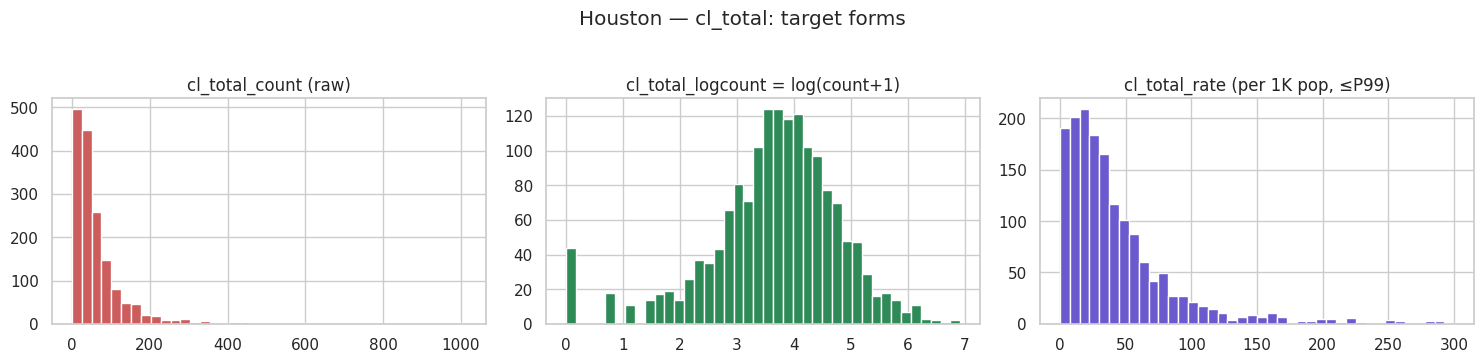

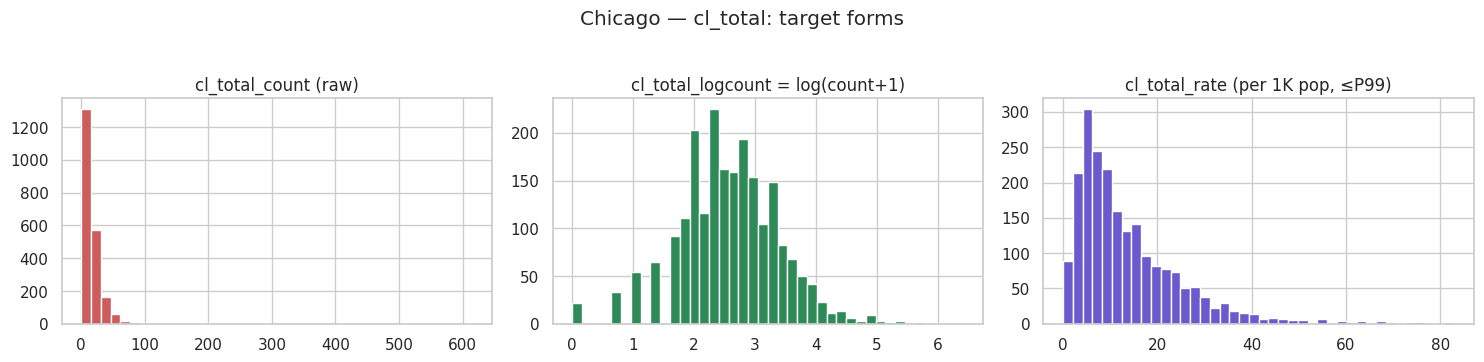

In [26]:
# Confirms log(count+1) tames the skew that raw counts show — justifying the OLS target.
def plot_target_forms(df, cat, city, rate_clip_pct=99):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    axes[0].hist(df[f"{cat}_count"], bins=40, color="indianred", edgecolor="white")
    axes[0].set_title(f"{cat}_count (raw)")
    axes[1].hist(df[f"{cat}_logcount"], bins=40, color="seagreen", edgecolor="white")
    axes[1].set_title(f"{cat}_logcount = log(count+1)")

    rate = df[f"{cat}_rate"].dropna()
    rate_range = (0, rate.quantile(rate_clip_pct / 100)) if rate_clip_pct else None
    axes[2].hist(rate, bins=40, range=rate_range, color="slateblue", edgecolor="white")
    axes[2].set_title(f"{cat}_rate (per 1K pop, ≤P{rate_clip_pct})")

    fig.suptitle(f"{city} — {cat}: target forms", y=1.03); fig.tight_layout(); plt.show()

for city, df in tables.items():
    plot_target_forms(df, "cl_total", city.title())

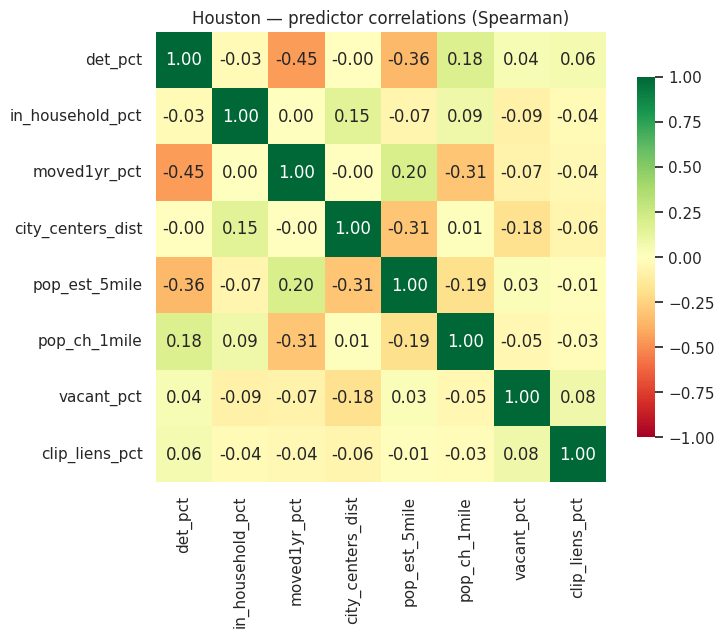

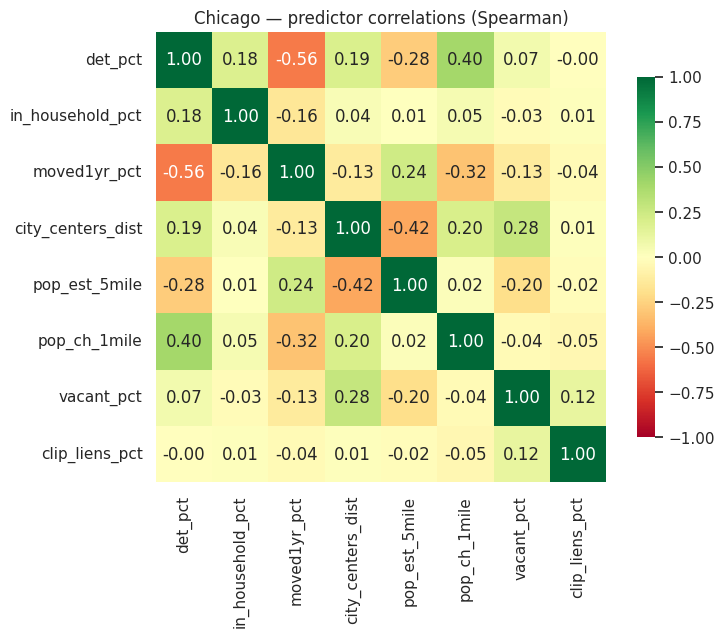

In [22]:
# Correlation heatmap
def corr_heatmap(df, cols, title):
    corr = df[cols].corr(method="spearman")
    fig, ax = plt.subplots(figsize=(8, 6.5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
                vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8}, ax=ax)
    ax.set_title(title); plt.tight_layout(); plt.show()

for city, df in tables.items():
    corr_heatmap(df, PREDICTOR_COLS, f"{city.title()} — predictor correlations (Spearman)")

In [27]:
# VIF calculation

def vif_table(df, cols):
    X = add_constant(df[cols].fillna(df[cols].median()))
    vif = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    })
    return vif[vif["feature"] != "const"].sort_values("VIF", ascending=False).round(2)

for city, df in tables.items():
    print(f"\n{city.upper()} — VIF")
    display(vif_table(df, PREDICTOR_COLS))


HOUSTON — VIF


,feature,VIF
5,pop_est_5mile,1.46
1,det_pct,1.43
3,moved1yr_pct,1.38
4,city_centers_dist,1.32
6,pop_ch_1mile,1.17
7,vacant_pct,1.08
2,in_household_pct,1.08
8,clip_liens_pct,1.01



CHICAGO — VIF


,feature,VIF
1,det_pct,1.59
3,moved1yr_pct,1.58
5,pop_est_5mile,1.50
4,city_centers_dist,1.44
6,pop_ch_1mile,1.41
7,vacant_pct,1.19
2,in_household_pct,1.10
8,clip_liens_pct,1.01


In [23]:
# Spearman of each predictor against each target (log-count). Directional preview
# of which predictors carry signal before fitting.
def predictor_target_corr(df, targets, suffix):
    tcols = [f"{t}_{suffix}" for t in targets]
    corr = df[PREDICTOR_COLS + tcols].corr(method="spearman").loc[PREDICTOR_COLS, tcols]
    corr.columns = targets
    return corr.round(2)

for city, df in tables.items():
    print(f"\n{city.upper()} — predictor vs target (Spearman, log-count)")
    display(predictor_target_corr(df, TARGET_CATEGORIES, "logcount"))


HOUSTON — predictor vs target (Spearman, log-count)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
det_pct,-0.16,-0.09,-0.17,-0.07,-0.02,-0.08,-0.09,-0.04,-0.17,-0.18
in_household_pct,-0.10,-0.11,-0.09,-0.11,-0.09,-0.09,-0.10,-0.09,-0.09,-0.04
moved1yr_pct,0.14,-0.05,0.18,-0.06,-0.01,0.02,-0.03,0.04,0.19,0.13
city_centers_dist,-0.18,-0.14,-0.18,-0.13,-0.07,-0.08,-0.13,-0.14,-0.18,-0.13
pop_est_5mile,0.14,0.04,0.16,-0.01,0.02,0.01,0.12,0.11,0.17,0.08
pop_ch_1mile,-0.15,0.03,-0.17,0.06,-0.02,-0.07,0.01,-0.07,-0.19,-0.08
vacant_pct,0.27,0.35,0.23,0.35,0.15,0.22,0.27,0.31,0.21,0.18
clip_liens_pct,0.06,0.04,0.05,0.05,0.06,0.01,0.03,0.06,0.05,0.03



CHICAGO — predictor vs target (Spearman, log-count)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
det_pct,-0.30,-0.18,-0.30,-0.14,-0.06,-0.14,-0.17,-0.09,-0.34,-0.11
in_household_pct,-0.11,-0.08,-0.11,-0.08,-0.02,-0.07,-0.07,-0.01,-0.12,-0.07
moved1yr_pct,0.19,0.00,0.23,-0.04,-0.02,0.08,0.06,0.06,0.28,0.02
city_centers_dist,-0.00,0.10,-0.03,0.12,-0.04,-0.00,0.03,0.09,-0.06,0.02
pop_est_5mile,-0.03,-0.08,-0.02,-0.12,-0.01,-0.00,0.00,-0.08,0.05,-0.13
pop_ch_1mile,-0.28,-0.19,-0.26,-0.17,-0.06,-0.10,-0.14,-0.09,-0.27,-0.16
vacant_pct,0.36,0.48,0.27,0.48,0.17,0.16,0.28,0.23,0.18,0.34
clip_liens_pct,0.12,0.13,0.09,0.13,0.04,0.04,0.10,0.07,0.08,0.11


In [29]:
# Correlations with rate
suffix="rate"
for city, df in tables.items():
    print(f"\n{city.upper()} — predictor vs target (Spearman, {suffix})")
    display(predictor_target_corr(df, TARGET_CATEGORIES, f"{suffix}"))


HOUSTON — predictor vs target (Spearman, rate)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
det_pct,-0.24,-0.16,-0.25,-0.13,-0.02,-0.11,-0.13,-0.10,-0.23,-0.26
in_household_pct,-0.08,-0.09,-0.07,-0.09,-0.09,-0.07,-0.08,-0.06,-0.08,-0.02
moved1yr_pct,0.19,-0.02,0.23,-0.04,-0.01,0.03,-0.01,0.06,0.24,0.18
city_centers_dist,-0.21,-0.16,-0.21,-0.15,-0.07,-0.09,-0.14,-0.16,-0.20,-0.16
pop_est_5mile,0.19,0.08,0.21,0.03,0.02,0.03,0.14,0.15,0.21,0.13
pop_ch_1mile,-0.17,0.02,-0.20,0.05,-0.02,-0.07,-0.00,-0.08,-0.21,-0.11
vacant_pct,0.32,0.41,0.28,0.40,0.15,0.24,0.30,0.36,0.26,0.23
clip_liens_pct,0.07,0.05,0.06,0.05,0.06,-0.00,0.03,0.06,0.06,0.04



CHICAGO — predictor vs target (Spearman, rate)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
det_pct,-0.23,-0.14,-0.23,-0.09,-0.06,-0.12,-0.15,-0.05,-0.28,-0.06
in_household_pct,-0.10,-0.07,-0.10,-0.07,-0.02,-0.07,-0.06,-0.01,-0.11,-0.06
moved1yr_pct,0.16,-0.02,0.20,-0.06,-0.02,0.07,0.05,0.05,0.26,-0.00
city_centers_dist,0.11,0.17,0.09,0.18,-0.04,0.02,0.07,0.15,0.04,0.11
pop_est_5mile,-0.11,-0.12,-0.10,-0.15,-0.01,-0.01,-0.02,-0.11,-0.02,-0.19
pop_ch_1mile,-0.26,-0.18,-0.26,-0.15,-0.06,-0.09,-0.13,-0.08,-0.27,-0.15
vacant_pct,0.49,0.54,0.41,0.54,0.18,0.18,0.32,0.28,0.30,0.43
clip_liens_pct,0.11,0.13,0.09,0.12,0.04,0.04,0.10,0.07,0.08,0.10
